# Superstore Satış Analizi  

**Proje Amacı:**  
Bu projede bir perakende şirketine ait satış verileri analiz edilerek satış performansı ve kârlılık yapısı incelenmiştir.
Amaç; hangi ürün kategorilerinin, bölgelerin ve müşteri segmentlerinin kârlılık üzerinde daha etkili olduğunu belirlemek ve veri üzerinden iş kararlarına katkı sağlayabilecek içgörüler (insight) elde etmektir.

Analiz sürecinde Pandas, Matplotlib ve Seaborn kütüphaneleri kullanılarak keşifsel veri analizi (EDA) gerçekleştirilmiştir.

**Kullanılan Teknolojiler:**  
- Python 3  
- Pandas  
- Matplotlib & Seaborn  
- Jupyter Notebook

Veri seti: Sample Superstore (Kaggle)



### Veri Kümesi Açıklaması

Bu veri kümesi, bir perakende mağazasından alınan işlem bazlı satış kayıtlarını içermektedir.

Ana sütunlar şunlardır:

Sales – Siparişten elde edilen toplam satış geliri

Profit – Siparişten elde edilen kâr veya zarar

Discount– Satışa uygulanan indirim oranı

Category - Ana ürün kategorisi (Furniture, Office Supplies, Technology)

Sub-Category - Ürün alt kategorisi (örneğin Phones, Chairs, Paper vb.)

Segment - Müşteri tipi (Consumer, Corporate, Home Office)

Region – coğrafi bölge

Order Date – Sipariş tarihi

 ### Keşifsel Veri Analizinin (EDA) 
  Bu analiz kapsamında aşağıdaki başlıklar incelenmiştir:
  
 - Kategorilere Göre Toplam Satış ve Kâr 

 - Alt Kategorilere Göre Kâr

 - En Çok Zarar Ettiren  Ürünler

 - İndirim Oranı vs Kâr

 - Bölge Bazlı Satış vs Kâr

 - Segmentlere Göre Satış Payı

  - Zaman Serisi Analizi: Aylık Satış, Kâr ve Kâr Marjı Trendi



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Görselleştirme ayarları
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12
%matplotlib inline

print("Kütüphaneler yüklendi.")

Kütüphaneler yüklendi.


# Veri Yükleme ,İlk Bakış ve Temizleme

In [4]:
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [6]:
df.shape

(9994, 21)

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [8]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [9]:
# Tarih sütunlarını datetime çevirme
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

print("sütunlar başarıyla datetime formatına çevrildi.")

sütunlar başarıyla datetime formatına çevrildi.


In [10]:
print("Tekrar eden satır sayısı:", df.duplicated().sum())

Tekrar eden satır sayısı: 0


#### Veri seti yüklendikten sonra genel yapı, sütun tipleri ve eksik değerler incelendi.
#### Tekrar eden satır kontrolü yapıldı.



# Kategorilere Göre Toplam Satış ve Kâr

In [13]:
kategori_analizi= df.groupby("Category")[["Sales", "Profit"]].sum().sort_values(by="Sales")
kategori_analizi

,Sales,Profit
Category,,
Office Supplies,719047.0320,122490.8008
Furniture,741999.7953,18451.2728
Technology,836154.0330,145454.9481


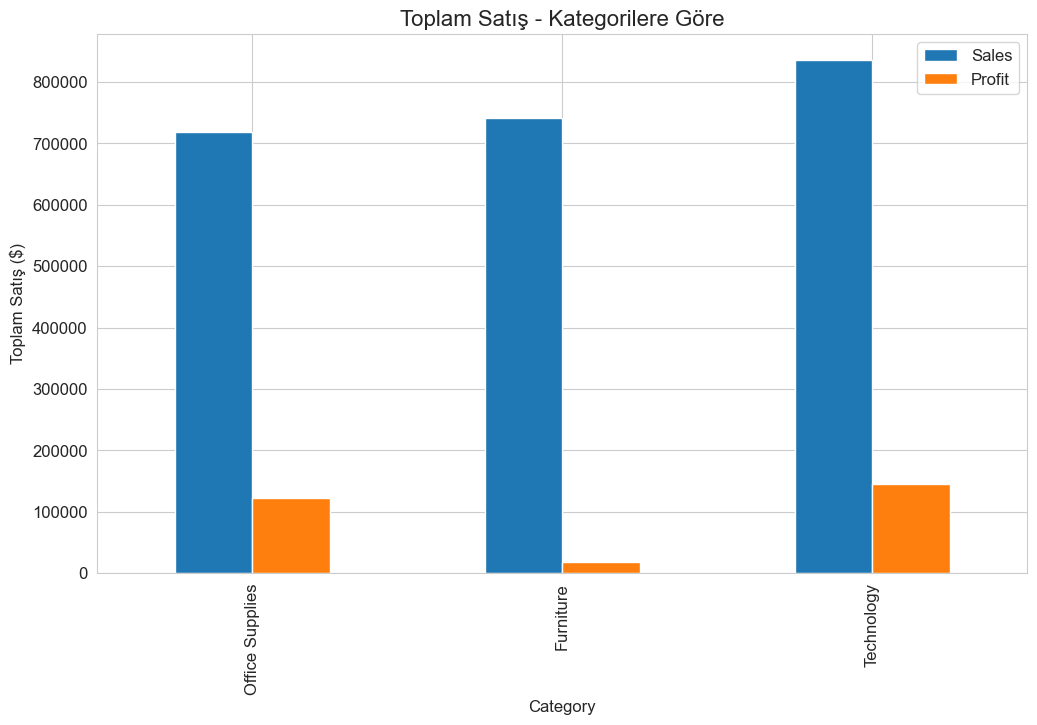

In [14]:
kategori_analizi.plot(kind="bar")
plt.title('Toplam Satış - Kategorilere Göre', fontsize=16)
plt.ylabel('Toplam Satış ($)')
plt.show()   


#### Technology kategorisi toplam satışların en büyük kısmını oluşturuyor.  
#### Furniture satış hacmi yüksek olsa da karlılık açısından riskli görünüyor .
#### Bu durum satış hacmi ile kârın her zaman doğru orantılı olmadığını göstermektedir


# Alt Kategorilere Göre Kârlılık

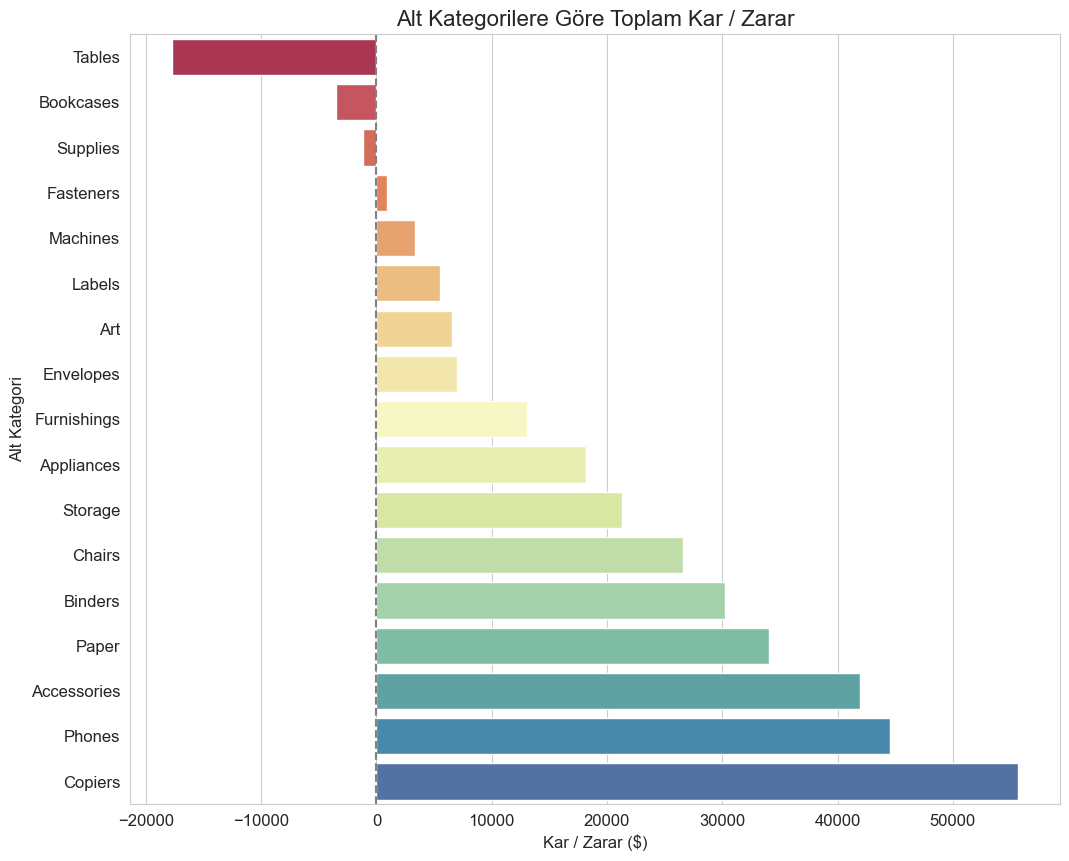

In [17]:
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=True)  # düşükten yükseğe

plt.figure(figsize=(12, 10))
sns.barplot( x=subcat_profit.values, y=subcat_profit.index, hue=subcat_profit.index, palette='Spectral', legend=False )

plt.title('Alt Kategorilere Göre Toplam Kar / Zarar', fontsize=16)
plt.xlabel('Kar / Zarar ($)')
plt.ylabel('Alt Kategori')
plt.axvline(0, color='gray', linestyle='--')
plt.show()

#### Tables ve Bookcases ciddi zarar ediyor.
#### Copiers, Phones, Accessories en karlı ürünler arsında yer alıyor.

 #### Bu sonuçlar bazı ürün gruplarında fiyatlandırma ,indirim oranı ve maliyet yapısının yeniden dikkatli değerlendirilmesi gerektiğini göstermektedir

## En Çok Zarar Ettiren  Ürünler

In [20]:
zarar_eden_10_urun= df.groupby("Product Name")[["Profit", "Sales"]].sum().sort_values(by="Profit").head(10)
zarar_eden_10_urun

,Profit,Sales
Product Name,,
Cubify CubeX 3D Printer Double Head Print,-8879.9704,11099.963
Lexmark MX611dhe Monochrome Laser Printer,-4589.9730,16829.901
Cubify CubeX 3D Printer Triple Head Print,-3839.9904,7999.980
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,-2876.1156,9917.640
Bush Advantage Collection Racetrack Conference Table,-1934.3976,9544.725
GBC DocuBind P400 Electric Binding System,-1878.1662,17965.068
Cisco TelePresence System EX90 Videoconferencing Unit,-1811.0784,22638.480
Martin Yale Chadless Opener Electric Letter Opener,-1299.1836,16656.200
Balt Solid Wood Round Tables,-1201.0581,6518.754


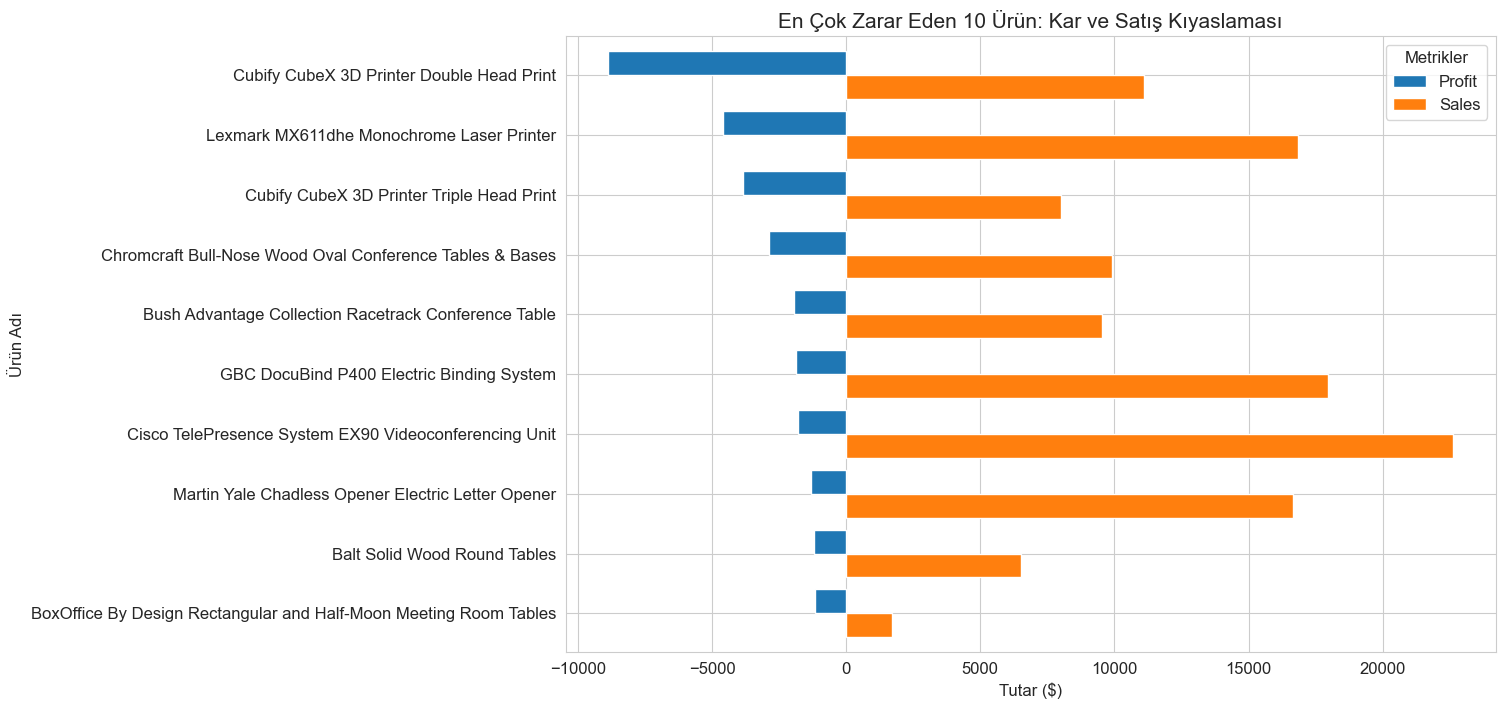

In [21]:
zarar_eden_10_urun.plot(kind='barh', figsize=(12, 8), width=0.8)

plt.title('En Çok Zarar Eden 10 Ürün: Kar ve Satış Kıyaslaması', fontsize=15)
plt.xlabel('Tutar ($)', fontsize=12)
plt.ylabel('Ürün Adı', fontsize=12)
plt.gca().invert_yaxis()  # En kötü olanın en üstte görünmesi için
plt.legend(title="Metrikler")
plt.show()

#### Bazı ürünler satış üretmesine rağmen ciddi zarar oluşturmaktadır.
#### Ürünlerde  yapılan yanlış fiyat politikaları ve satışının  sonucu görülmektedir.



 # İndirim Oranı vs Kâr

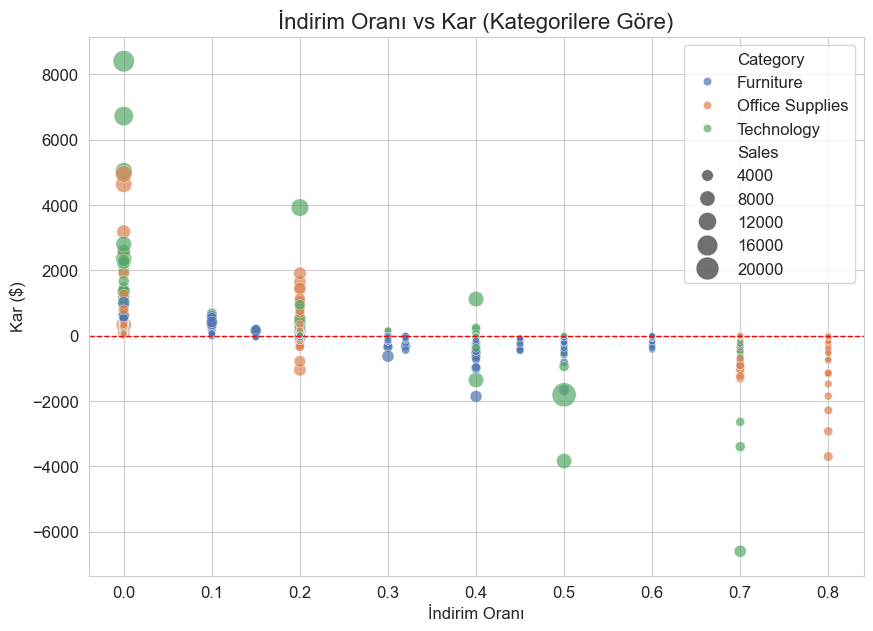

In [24]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', size='Sales',
                palette='deep', alpha=0.7, sizes=(20, 300))

plt.title('İndirim Oranı vs Kar (Kategorilere Göre)', fontsize=16)
plt.xlabel('İndirim Oranı')
plt.ylabel('Kar ($)')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.show()


#### İndirim %20’nin üstüne çıktığında neredeyse her zaman zarar başlıyor.

#### Technology ürünleri %20’nin üstüne indirimde bile karlı kalabiliyor.
#### Bu durum ürün kategorilerine göre farklı fiyatlandırma stratejileri uygulanabileceğini göstermektedir.


# Bölge Bazlı Satış vs Kâr

In [27]:
Bolge_analızı = df.groupby("Region")[["Sales", "Profit"]].sum().sort_values(by="Sales",ascending=False)
Bolge_analızı

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


In [28]:
# Bölgelere göre ortalama indirim oranını 
df.groupby("Region")["Discount"].mean()

Region
Central    0.240353
East       0.145365
South      0.147253
West       0.109335
Name: Discount, dtype: float64

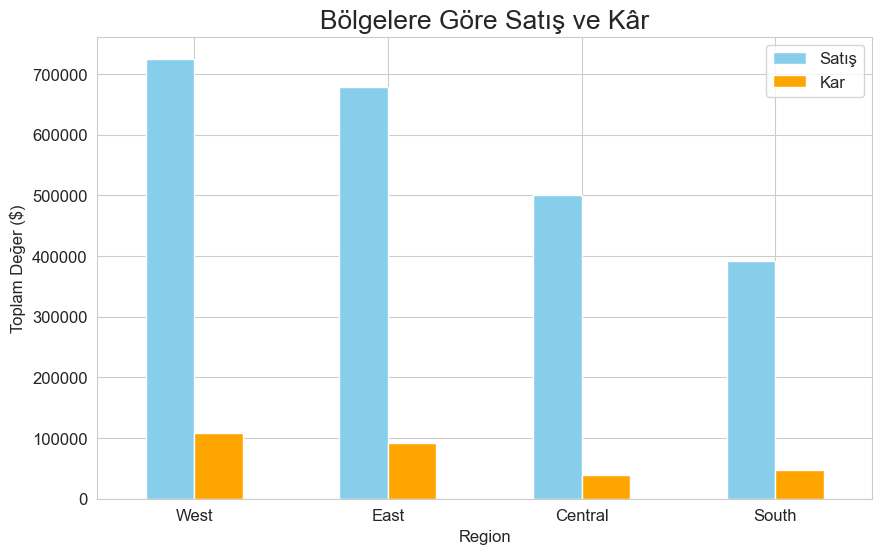

In [29]:

Bolge_analızı.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'orange'])
plt.title('Bölgelere Göre Satış ve Kâr', fontsize=19)
plt.ylabel('Toplam Değer ($)')
plt.xticks(rotation=0)
plt.legend(['Satış', 'Kar'])

plt.show()


#### West bölgesi en yüksek satış ve karı üretiyor.

#### Central bölgesinde kar satışına göre düşük kalıyor.

#### Bu durum bölgesel operasyon maliyetleri veya uygulanan indirim politikalarının farklılık göstermesi ile ilişkili olabilir.

# Segmentlere Göre Satış Payı

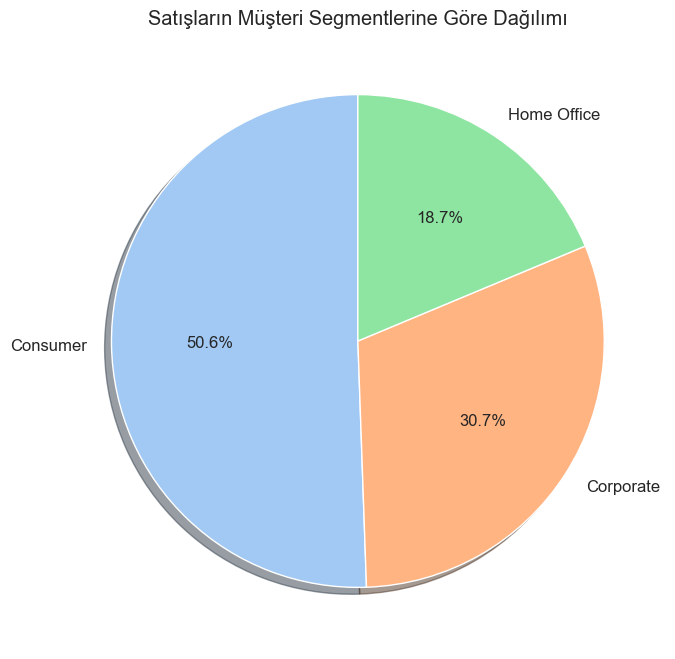

In [32]:
segment_satıs = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(8, 8))
plt.pie(segment_satıs, labels=segment_satıs.index, autopct='%1.1f%%', 
        colors=sns.color_palette('pastel'), startangle=90, shadow=True)
plt.title('Satışların Müşteri Segmentlerine Göre Dağılımı')
plt.show()

#### Consumer segmenti satışların yarısından fazlasını oluşturuyor.

In [34]:
segment_analızı= df.groupby("Segment")[["Sales", "Profit"]].sum().round(3)

# Kâr oranını  (yüzde cinsinden)
segment_analızı['kar_oranı'] = (segment_analızı['Profit'] / segment_analızı['Sales']) * 100

# Sonucu daha rahat okumak için kâr oranına göre sıralayalım
segment_analızı = segment_analızı.sort_values(by='kar_oranı', ascending=False)

segment_analızı

,Sales,Profit,kar_oranı
Segment,,,
Home Office,429653.148,60298.678,14.034269
Corporate,706146.367,91979.134,13.025506
Consumer,1161401.345,134119.209,11.548050


#### Home Office segmenti en düşük satış hacmine sahip olmasına rağmen %14.03 ile en yüksek kâr oranını sağlamaktadır. 
#### Consumer segmenti toplam satışların en büyük kısmını oluşturmasına rağmen %11.55 ile kâr marjı en düşük gruptur.


                           Sales      Profit  kar_oranı
Segment     Region                                     
Consumer    West     362880.7730  57450.6040  15.831813
            South    195580.9710  26913.5728  13.760834
            East     350908.1670  41190.9843  11.738394
            Central  252031.4340   8564.0481   3.398008
Corporate   West     225855.2745  34437.4299  15.247565
            South    121885.9325  15215.2232  12.483166
            Central  157995.8128  18703.9020  11.838226
            East     200409.3470  23622.5789  11.787164
Home Office East     127463.7260  26709.2168  20.954367
            Central   91212.6440  12438.4124  13.636719
            West     136721.7770  16530.4150  12.090550
            South     74255.0015   4620.6343   6.222657


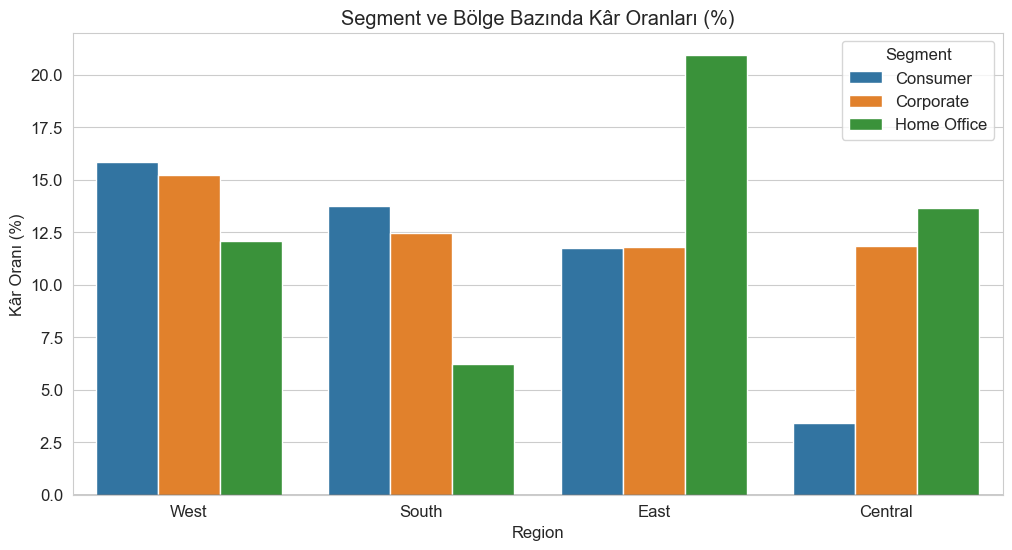

In [36]:

segment_bolge = df.groupby(['Segment', 'Region'])[['Sales', 'Profit']].sum()


segment_bolge['kar_oranı'] = (segment_bolge['Profit'] / segment_bolge['Sales']) * 100


segment_bolge = segment_bolge.sort_values(by=['Segment', 'kar_oranı'], ascending=[True, False])

print(segment_bolge)


plt.figure(figsize=(12, 6))
sns.barplot(data=segment_bolge.reset_index(), x='Region', y='kar_oranı', hue='Segment')
plt.title('Segment ve Bölge Bazında Kâr Oranları (%)')
plt.ylabel('Kâr Oranı (%)')
plt.axhline(0, color='black', linewidth=1)
plt.show()

#### Bölgesel ve segment bazlı veriler, şirketin kârlılık yapısının coğrafi konuma göre ciddi şekilde etkilendiğini göstermektedir.

#### Home Office segmenti East bölgesinde %20,95 gibi çok yüksek bir verimlilikle çalışırken, Consumer segmentinin Central bölgesinde %3,39 gibi kritik bir seviyeye gerilemesi, operasyonel maliyetlerin veya indirim oranlarının bölge bazlı kontrol edilmesi gerektiğini gösterir. 

#### West ise  satışlarda %10 barajını aşarak şirketin en sağlıklı ve sürdürülebilir kâr merkezi olarak öne çıkmaktadır.

#### Bölgesel analiz ile birlikte değerlendirildiğinde şirketin kârlılık yapısının coğrafi konuma göre önemli ölçüde değiştiği görülmektedir.

# Zaman Serisi Analizi: Aylık Satış, Kâr ve Kâr Marjı Trendi

#### Satış ve kârlılığın zaman içindeki değişimini incelemek amacıyla aylık bazda bir analiz yapıldı.

#### Öncelikle sipariş tarihleri yıl ve ay seviyesine indirgenmiş,
#### ardından her ay için toplam satış ve toplam kâr hesaplanmıştır. Bu değerler kullanılarak kâr marjı hesaplanmıştır.

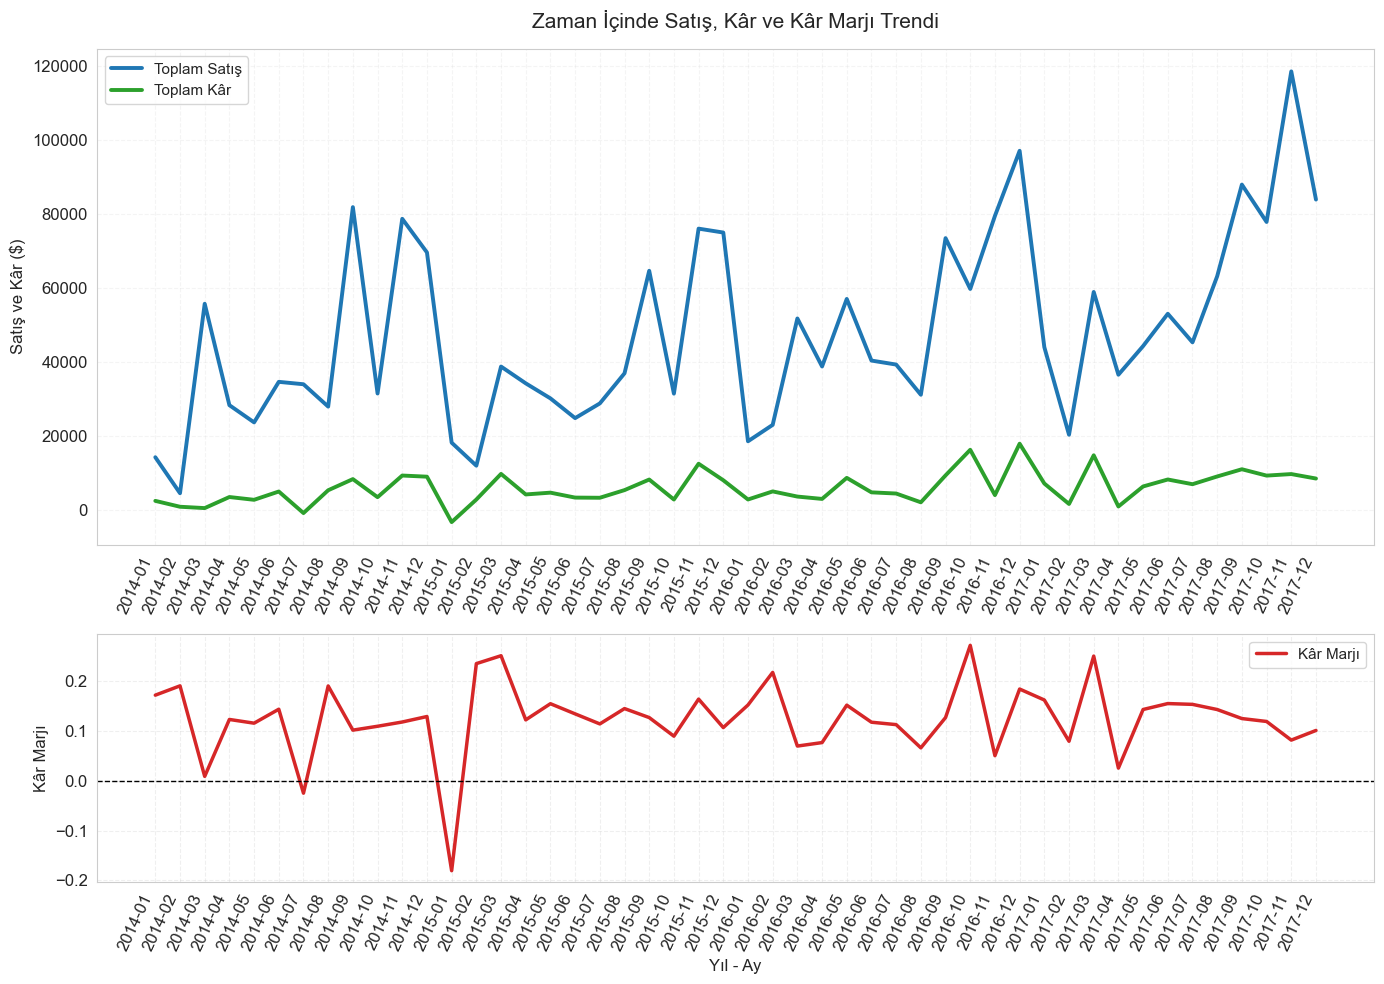

In [39]:
# Yıl-Ay göre periyot oluşturma
df['YilAy'] = df['Order Date'].dt.to_period('M')

# Özet tablo
aylik_ozet = df.groupby('YilAy').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

aylik_ozet['Kar Marji'] = aylik_ozet['Profit'] / aylik_ozet['Sales']

# ====================== GRAFİK ======================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), height_ratios=[2, 1])

# ÜST GRAFİK 
ax1.plot(aylik_ozet['YilAy'].astype(str), aylik_ozet['Sales'], 
         label='Toplam Satış', color='#1f77b4', linewidth=2.8)
ax1.plot(aylik_ozet['YilAy'].astype(str), aylik_ozet['Profit'], 
         label='Toplam Kâr', color='#2ca02c', linewidth=2.8)

ax1.set_ylabel('Satış ve Kâr ($)', fontsize=12)
ax1.set_title('Zaman İçinde Satış, Kâr ve Kâr Marjı Trendi', fontsize=15, pad=15)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.2, linestyle='--')   

# ALT GRAFİK 
ax2.plot(aylik_ozet['YilAy'].astype(str), aylik_ozet['Kar Marji'], 
         label='Kâr Marjı', color='#d62728', linewidth=2.5)

ax2.set_ylabel('Kâr Marjı', fontsize=12)
ax2.set_xlabel('Yıl - Ay', fontsize=12)
ax2.legend(fontsize=11)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.grid(True, alpha=0.3, linestyle='--')  


plt.setp(ax1.xaxis.get_majorticklabels(), rotation=65, ha='right')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=65, ha='right')

plt.tight_layout()
plt.show()

In [40]:
aylik_ozet.head (12)

,YilAy,Sales,Profit,Kar Marji
0,2014-01,14236.8950,2450.1907,0.172101
1,2014-02,4519.8920,862.3084,0.190781
2,2014-03,55691.0090,498.7299,0.008955
3,2014-04,28295.3450,3488.8352,0.123301
4,2014-05,23648.2870,2738.7096,0.115810
5,2014-06,34595.1276,4976.5244,0.143850
6,2014-07,33946.3930,-841.4826,-0.024789
7,2014-08,27909.4685,5318.1050,0.190548
8,2014-09,81777.3508,8328.0994,0.101839
9,2014-10,31453.3930,3448.2573,0.109631


#### - Bazı dönemlerde satış yüksek olmasına rağmen kâr marjının düşük kaldığı gözlemlenmektedir. Örneğin 2014 yılının Mart ayında satış yüksek olmasına rağmen kâr marjı oldukça düşüktür.

#### Ayrıca bazı aylarda kâr marjının negatif olduğu görülmektedir. Bu durum şirketin belirli dönemlerde zarar ettiğini göstermektedir.

#### - Satışlar 2014’ten 2017’ye doğru **genel olarak artan** bir trend gösteriyor. Özellikle 2016 ve 2017’de belirgin büyüme var.
#### - Kâr miktarı da artış gösterse de **daha dalgalı** bir yapıya sahip. Bazı aylarda (örneğin 2014-07 ve 2015-01) zarar edildiği         görülüyor.
#### - Kâr marjı genellikle %10 - %25 bandında hareket ediyor. En yüksek kâr marjı 2016 Ekim’de (%27.2) gerçekleşmiş.
.

# Sonuç ve Genel Değerlendirme

Bu analiz sonucunda aşağıdaki temel bulgular elde edilmiştir:

 - Technology kategorisi şirket için en güçlü gelir ve kâr kaynağıdır.

  - Furniture kategorisi yüksek satış hacmine rağmen düşük/negatif kâr marjı üretmektedir

  - Yüksek indirim oranları kârlılığı ciddi şekilde düşürmektedir.

  - West bölgesi şirketin en güçlü satış ve kâr merkezidir.

  - Consumer segmenti yüksek satış hacmine sahip olmasına rağmen verimlilik açısından daha düşük performans göstermektedir.

  

Bu sonuçlar şirket için fiyatlandırma stratejileri, indirim politikaları ve ürün portföyü yönetimi açısından önemli içgörüler sunmaktadır.